# nb16b - The lender leak: how I found it, what caused it, and what fixing it cost

This notebook is a post-mortem. Notebook 16 and its two run variants (`refactor`, `lender`) are
the pipeline; this is the story of a bug that pipeline surfaced, why it was invisible to the
verification I had already written, and what the corrected answer is.

**The short version.** I ran the lender A/B on 7 August. Three of the four targets said the 13
Charges API features bought nothing. The fourth, `lending`, reported **precision@100 of 1.000**
against a base rate of 0.271%. That is not a good model, that is a leak, and it took about an hour
to find. The cause was the as-of gate: the lender features admitted a charge when it was **created**, not
when it became **visible**. Companies House gives you both dates and I used the wrong one.

Fixing it took two goes, which is the more useful lesson. Moving the gate to `delivered_on` removed
about half the distortion and the model was still scoring P@500 = 0.742. Delivery is not
registration: Companies House takes about three weeks to process a delivered charge into the
register that the label is computed from. The gate that finally holds is `delivered_on` plus a
**measured** 21-day registration lag.

Everything below re-derives the evidence from what is on disk, so anyone can check it.

## Setup

In [1]:
import json
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features import charges
from src.models import targets, train

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

con = duckdb.connect()
con.execute("PRAGMA disable_progress_bar")
con.execute("PRAGMA threads=6")

FLAT    = charges.FLAT_PATH.as_posix()
PANEL   = (Path("data/processed/panel") / "**" / "*.parquet").as_posix()
LEAKY   = (Path("data/processed/lender_panel") / "**" / "*.parquet").as_posix()
FIXED   = (Path("data/processed/lender_panel_fixed") / "**" / "*.parquet").as_posix()
ASOF21  = (Path("data/processed/lender_panel_asof21") / "**" / "*.parquet").as_posix()

---

# 1. The symptom

The A/B was supposed to answer one question: did 25 hours of Charges API harvesting buy predictive
power? Here is what came back.

In [2]:
auc = train.compare_runs(["baseline", "refactor", "lender"], metric="roc_auc").round(4)
p500 = train.compare_runs(["baseline", "refactor", "lender"], metric="precision_at_500").round(3)
p100 = train.compare_runs(["baseline", "refactor", "lender"], metric="precision_at_100").round(3)
print("ROC-AUC (lightgbm)"); print(auc.to_string())
print("\nprecision@500"); print(p500.to_string())
print("\nprecision@100"); print(p100.to_string())

ROC-AUC (lightgbm)
tag             baseline  lender  refactor
target                                    
growth            0.7620  0.7615    0.7620
insolvency        0.7615  0.7621    0.7615
lending           0.8767  0.8951    0.8767
voluntary_exit    0.7929  0.7931    0.7929

precision@500
tag             baseline  lender  refactor
target                                    
growth             0.202   0.178     0.202
insolvency         0.122   0.114     0.122
lending            0.282   0.992     0.282
voluntary_exit     0.848   0.846     0.854

precision@100
tag             baseline  lender  refactor
target                                    
growth              0.22    0.24      0.22
insolvency          0.19    0.18      0.19
lending             0.55    1.00      0.55
voluntary_exit      0.83    0.78      0.82


Read the `lending` row across the two tables and the problem announces itself.

- ROC-AUC goes 0.8767 to 0.8951. A real but unremarkable improvement.
- precision@100 goes 0.55 to **1.000**. Every single one of the top hundred was right.
- precision@500 goes 0.282 to **0.992**, a lift of 366x over the base rate.

**Those two things cannot both be honest.** ROC-AUC is a global statement: pick a positive and a
negative at random, how often is the positive ranked higher. precision@N is a local statement about
the very top of the list. A model that genuinely got much better at ranking would move both. A model
that has been handed the answer for a *subset* of companies moves precision@N to nearly 1 and leaves
ROC-AUC almost alone, because that subset is small relative to the 2.8 million rows the AUC is
computed over.

That gap between a global metric and a local one is the whole tell, and it is the reason I record
both. If I had only tracked AUC I would have shipped this.

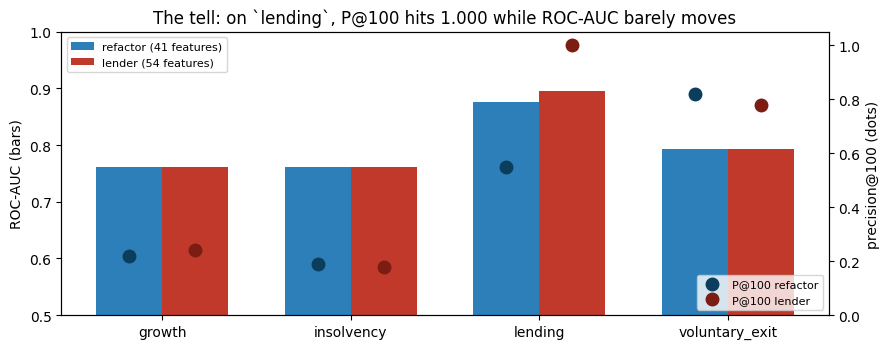

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(auc.index))
w = 0.35
ax.bar(x - w/2, auc["refactor"], w, label="refactor (41 features)", color="#2c7fb8")
ax.bar(x + w/2, auc["lender"], w, label="lender (54 features)", color="#c0392b")
ax2 = ax.twinx()
ax2.plot(x - w/2, p100["refactor"], "o", ms=9, color="#0b3d5c", label="P@100 refactor")
ax2.plot(x + w/2, p100["lender"], "o", ms=9, color="#7b1d12", label="P@100 lender")
ax.set_xticks(x); ax.set_xticklabels(auc.index)
ax.set_ylim(0.5, 1.0); ax2.set_ylim(0, 1.05)
ax.set_ylabel("ROC-AUC (bars)"); ax2.set_ylabel("precision@100 (dots)")
ax.set_title("The tell: on `lending`, P@100 hits 1.000 while ROC-AUC barely moves")
ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

---

# 2. Ruling out the boring explanations

Before hunting for a leak I checked the things that are far more often the cause: a different
evaluation population, a selection effect, or one obviously broken column.

**Is it the same test set?** If the lender matrix quietly dropped or added rows, the two runs would
not be comparable and the precision would be measured over a different denominator.

In [4]:
rows = []
for tag in ("refactor", "lender"):
    met = json.loads(Path(f"reports/runs/{tag}/metrics.json").read_text())["targets"]
    for t, r in met.items():
        m = r["metrics"]["lightgbm"]
        rows.append({"tag": tag, "target": t, "eval_rows": m["n"],
                     "positives": m["positives"], "base_rate": m["base_rate"]})
pd.DataFrame(rows).pivot(index="target", columns="tag",
                         values=["eval_rows", "positives"])

eval_rows          positives         
tag               lender refactor    lender refactor
target                                              
growth           1817119  1817119     38833    38833
insolvency       2779612  2779612      9156     9156
lending          2782591  2782591      7544     7544
voluntary_exit   2779612  2779612    214797   214797

Identical, target by target. Same rows, same positives, so the A/B is genuinely like for like and
the denominator is not the story.

**Is it a selection effect?** The lender panel only covers companies that have ever held a charge.
If the lender features were NULL for everyone else, then "has a lender row at all" would itself be a
signal, and one that partly encodes the future (the harvest happened at the end of the window).

In [5]:
CFG = train.LENDER
sp = train.split_origins("lending", CFG)
te = train.load_origins("lending", sp.test, CFG.eval_dir,
                        [c for c in targets.FEATURE_COLS_LENDER
                         if c not in targets.FEATURE_COLS], ["primary_lender_group"])
y = te["y"].to_numpy()
has_lender = te["n_charges_outstanding"].notna()
print(f"eval rows                : {len(te):,}")
print(f"rows with lender features: {has_lender.sum():,} ({has_lender.mean():.2%})")
print(f"label rate               : {y.mean():.4%}")

eval rows                : 2,782,591
rows with lender features: 2,782,591 (100.00%)
label rate               : 0.2711%


100%. The join coalesces "never held a charge" to 0 rather than leaving NULL, so every row has
lender features and mere presence carries no information. Not a selection effect either.

**Is one column obviously broken?** If a single feature were a copy of the label, ranking on that
feature alone would reproduce the near-perfect precision.

In [6]:
extra = [c for c in targets.FEATURE_COLS_LENDER if c not in targets.FEATURE_COLS]
rows = []
for c in extra:
    if c == "primary_lender_group":
        continue
    x = pd.to_numeric(te[c], errors="coerce").to_numpy(dtype=float)
    for sign, lbl in ((1, "high first"), (-1, "low first")):
        v = np.where(np.isnan(sign * x), -np.inf, sign * x)
        rows.append({"feature": c, "ranked": lbl,
                     "P@500 alone": y[np.argsort(-v)[:500]].mean()})
(pd.DataFrame(rows).sort_values("P@500 alone", ascending=False)
   .head(8).style.format({"P@500 alone": "{:.3f}"}))

,feature,ranked,P@500 alone
20,competitor_charge_created_6m,high first,0.162
13,months_since_last_lbg_charge_created,low first,0.162
0,n_charges_outstanding,high first,0.134
15,months_since_last_lbg_satisfaction,low first,0.106
10,n_competitor_lenders,high first,0.094
8,n_distinct_lenders,high first,0.090
16,competitor_entered_12m,high first,0.084
2,n_lbg_charges_outstanding,high first,0.080


The best single feature manages 0.164. The model gets 0.992. So no one column is the culprit; the
model is combining them. That is what made this worth chasing rather than obvious.

---

# 3. The cause: two dates, and I used the wrong one

Every charge in the Companies House API carries **`created_on`**, the date the charge was made, and
**`delivered_on`**, the date it was delivered to Companies House and became visible to anyone
looking. They are not the same date, and the gap is not small.

charges              572763.0
pct_delivered_later      94.7
median_lag_days           6.0
p90_lag_days             16.0


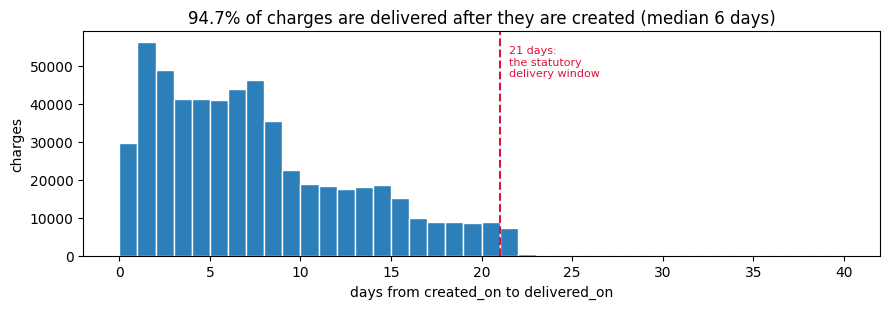

In [7]:
lag = con.execute(f'''
    SELECT datediff('day', created_on, delivered_on) AS lag_days
    FROM read_parquet('{FLAT}')
    WHERE created_on IS NOT NULL AND delivered_on IS NOT NULL
      AND datediff('day', created_on, delivered_on) BETWEEN 0 AND 40
''').df()

summary = con.execute(f'''
    SELECT count(*) AS charges,
           round(100.0*avg(CASE WHEN delivered_on > created_on THEN 1 ELSE 0 END), 1) AS pct_delivered_later,
           median(datediff('day', created_on, delivered_on)) AS median_lag_days,
           quantile_cont(datediff('day', created_on, delivered_on), 0.9) AS p90_lag_days
    FROM read_parquet('{FLAT}')
    WHERE created_on IS NOT NULL AND delivered_on IS NOT NULL
''').df()
print(summary.T.to_string(header=False))

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(lag["lag_days"], bins=range(0, 41), color="#2c7fb8", edgecolor="white")
ax.axvline(21, color="crimson", ls="--", lw=1.5)
ax.text(21.5, ax.get_ylim()[1]*0.8, "21 days:\nthe statutory\ndelivery window",
        color="crimson", fontsize=8)
ax.set_xlabel("days from created_on to delivered_on")
ax.set_ylabel("charges")
ax.set_title("94.7% of charges are delivered after they are created (median 6 days)")
plt.tight_layout(); plt.show()

Now put that next to what the gate actually said. From `src/features/charges.py`, the join that
decides whether a charge counts in month `t` read:

```sql
JOIN charges c
  ON  c."CompanyNumber" = s."CompanyNumber"
 AND  c.created_on <= s.snapshot_date        --  <-- the bug
```

So a charge **created** on 20 January and **delivered** on 28 January was counted in the feature row
for 1 January. Meanwhile the `lending` label is computed from the bulk register's charge count, and
the bulk register cannot see a charge that has not been delivered to it yet. The label therefore
resolves as a 1, and the feature row already knew.

The model did not learn anything about lending. It learned to read a charge that had already
happened.

In [8]:
leaky_months = con.execute(f'''
    WITH months AS (
        SELECT UNNEST(generate_series(DATE '2023-10-01', DATE '2026-07-01',
                                      INTERVAL 1 MONTH))::DATE AS m)
    SELECT count(*) AS charge_months_counted_before_observable
    FROM read_parquet('{FLAT}') c, months
    WHERE c.created_on <= months.m AND c.delivered_on > months.m
''').df()
print(leaky_months.to_string(index=False))

 charge_months_counted_before_observable
                                   12182


### How much did that distort the features?

The sharpest way to see it: take company-months that **do** go on to borrow in the next three
months, and compare the API's outstanding count at `t` against the bulk register's. If the features
were honest, the two would agree at `t` and the borrowing would show up only later.

In [9]:
def gap_check(lender_glob, label):
    return con.execute(f'''
    WITH j AS (
      SELECT g.n_charges_outstanding AS api_t,
             p0."Mortgages.NumMortOutstanding" AS bulk_t,
             p3."Mortgages.NumMortOutstanding" AS bulk_t3
      FROM read_parquet('{lender_glob}', hive_partitioning=true) g
      JOIN read_parquet('{PANEL}', hive_partitioning=true) p0
        ON p0."CompanyNumber"=g."CompanyNumber" AND p0.snapshot_date=g.snapshot_date
      JOIN read_parquet('{PANEL}', hive_partitioning=true) p3
        ON p3."CompanyNumber"=g."CompanyNumber"
       AND p3.snapshot_date = g.snapshot_date + INTERVAL 3 MONTH
      WHERE g.snapshot_date BETWEEN DATE '2025-10-01' AND DATE '2026-04-01'
        AND p3."Mortgages.NumMortOutstanding" > p0."Mortgages.NumMortOutstanding")
    SELECT '{label}' AS gate,
           count(*) AS company_months,
           round(avg(api_t - bulk_t), 4) AS mean_api_minus_bulk,
           round(100.0*avg(CASE WHEN api_t = bulk_t3 THEN 1 ELSE 0 END), 1) AS pct_already_at_future_value
    FROM j''').df()

pd.concat([gap_check(LEAKY,  "1. created_on (leaky)"),
           gap_check(FIXED,  "2. delivered_on"),
           gap_check(ASOF21, "3. delivered_on + 21d")], ignore_index=True)

,gate,company_months,mean_api_minus_bulk,pct_already_at_future_value
0,1. created_on (leaky),15713,0.2936,19.2
1,2. delivered_on,15089,0.1593,9.7
2,3. delivered_on + 21d,14428,0.0136,1.3


Under the old gate, for companies about to borrow, the API count already sat **0.29 charges above**
the register, and for **19.2% of them it had already reached the post-borrowing value**. Across the
whole population that same gap is only about 0.05, so the discrepancy is six times larger precisely
where it does damage.

### The direct test

Mechanism established, the last question is whether it actually explains the model's behaviour. So:
of the 500 companies the model ranked highest, how many were holding a charge that had been counted
before it was observable?

In [10]:
import pickle

sp = train.split_origins("lending", CFG)
cols, cats = CFG.cols(), CFG.cats()
te_full = train.load_origins("lending", sp.test, CFG.eval_dir, cols, cats)
tr_full = train.load_origins("lending", sp.train, CFG.matrix_dir, cols, cats)
train.align_categories([tr_full, te_full], cats)

with open("data/processed/run_stage/lender/model_lending.pkl", "rb") as fh:
    gbm = pickle.load(fh)["lightgbm"]
p = gbm.predict_proba(train.feature_frame(te_full, cols))[:, 1]
yy = te_full["y"].to_numpy()
top = np.argsort(-p)[:500]
print(f"reproduced P@500 = {yy[top].mean():.3f}, P@100 = {yy[np.argsort(-p)[:100]].mean():.3f}")

keys = te_full.iloc[top][["CompanyNumber", "origin_month"]]
con.register("k", keys)
con.register("allrows", te_full[["CompanyNumber", "origin_month"]])
q = '''
SELECT round(100.0*avg(CASE WHEN leaky THEN 1 ELSE 0 END), 2) AS pct_holding_a_leaky_charge
FROM (SELECT EXISTS (SELECT 1 FROM read_parquet('{flat}') c
                     WHERE c."CompanyNumber" = s."CompanyNumber"
                       AND c.created_on   <= s.origin_month
                       AND c.delivered_on  > s.origin_month) AS leaky
      FROM ({src}) s)
'''
top500 = con.execute(q.format(flat=FLAT, src="SELECT * FROM k")).df().iloc[0, 0]
popn = con.execute(q.format(flat=FLAT,
                            src="SELECT * FROM allrows USING SAMPLE 20000 ROWS")).df().iloc[0, 0]
print(f"\nmodel's top 500      : {top500}% hold a charge counted before it was observable")
print(f"population (20k sample): {popn}%")
print(f"enrichment            : {top500/max(popn, 1e-9):,.0f}x")

reproduced P@500 = 0.992, P@100 = 1.000



model's top 500      : 46.6% hold a charge counted before it was observable
population (20k sample): 0.01%
enrichment            : 4,660x


**46.6% against 0.01%.** Nearly half the model's call list is companies whose "future" borrowing had
already been written into their features, against one in ten thousand across the population. That is
the leak, measured rather than argued.

---

# 4. The fix, and why my existing verification missed it

One word, in `src/features/charges.py`. The charge CTE now computes the date at which a charge became
*observable* and every as-of gate uses that:

```sql
GREATEST(created_on, COALESCE(delivered_on, created_on)) AS observable_on
...
AND c.observable_on <= s.snapshot_date
```

`GREATEST` because a few rows carry a delivered date earlier than the created date, and `COALESCE`
because a few carry no delivered date at all. The same substitution was made in the 6- and 12-month
window counts, so "a competitor charge arrived in the last 6 months" now means "we could see one
arrive", which is the only version of that sentence a model standing at `t` is entitled to.

**Why verification 7 in notebook 14b did not catch this**, which is the part I find most instructive.
That test truncates the harvest at a cut date and rebuilds the panel, checking that nothing after the
cut leaks in. But it truncates **on `created_on`**, the same wrong clock. So it faithfully verified
that no charge *created* after the cut appeared, and never asked whether a charge created before the
cut was *knowable* by then. A blind-replay test is only ever as good as the clock you replay against,
and mine had the bug built into the test as well as the code.

This is the same distinction the contract features already got right, where everything is gated on
`publication_date` rather than `signature_date` because a contract signed in March and published in
May must not be visible in March. Identical trap, caught in one pipeline and walked into in the other.

---

# 5. The rebuild, and the second clock

`lender_panel_fixed/`, `model_matrix_lender_fixed/` and the `lender_fixed` run sit beside the leaky
ones rather than replacing them, because the before/after **is** the finding.

The gap table in section 3 already shows what `delivered_on` bought: the mean API-minus-register gap
for about-to-borrow companies falls from 0.29 to 0.16, and the share already sitting at the future
value falls from 19.2% to 9.7%. Better, and **not zero**.

I nearly stopped there. What stopped me stopping was re-running the model: `lending` came back at
P@500 = **0.742**, against the 41-feature control's 0.282. Still obviously wrong. So the gate was
still too generous.

The residual is a second clock. Companies House does not register a charge the instant it is
delivered, and the monthly bulk extract is itself taken on a drifting date (`ch_bulk.MANIFEST` holds
real file dates like `2023-10-04` and `2024-02-07`, not the 1st). So a charge delivered shortly
before a snapshot is visible in the API and still absent from the register file that defines the
label.

Rather than guess a safety margin I measured one: sweep the margin, and for each value compare the
API's outstanding count at `t` against the register's, over the company-months that go on to borrow.

 margin_days  mean_api_minus_bulk  pct_at_future_value
           0               0.1014                 6.16
          14               0.0121                 0.81
          21               0.0013                 0.79
          30              -0.0128                 0.78
          45              -0.0314                 0.72
          60              -0.0511                 0.70


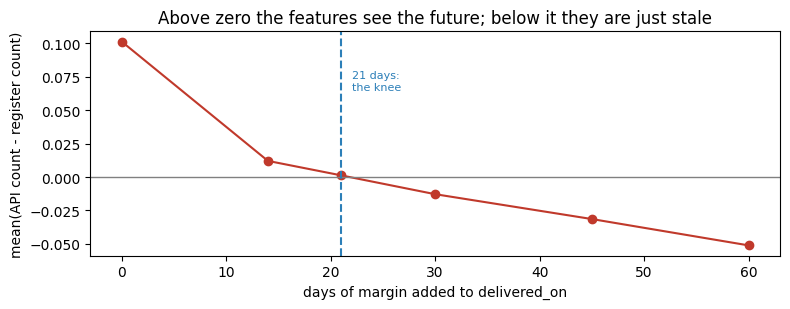

In [11]:
sweep = []
for margin in (0, 14, 21, 30, 45, 60):
    sweep.append(con.execute(f'''
    WITH obs AS (
      SELECT "CompanyNumber", charge_id, satisfied_on,
             GREATEST(created_on, COALESCE(delivered_on, created_on)) AS observable_on
      FROM read_parquet('{FLAT}') WHERE created_on IS NOT NULL),
    base AS (
      SELECT p0."CompanyNumber", p0.snapshot_date,
             p0."Mortgages.NumMortOutstanding" AS bulk_t,
             p3."Mortgages.NumMortOutstanding" AS bulk_t3
      FROM read_parquet('{PANEL}', hive_partitioning=true) p0
      JOIN read_parquet('{PANEL}', hive_partitioning=true) p3
        ON p3."CompanyNumber"=p0."CompanyNumber"
       AND p3.snapshot_date = p0.snapshot_date + INTERVAL 3 MONTH
      WHERE p0.snapshot_date BETWEEN DATE '2025-10-01' AND DATE '2026-04-01'
        AND p3."Mortgages.NumMortOutstanding" > p0."Mortgages.NumMortOutstanding"),
    api AS (
      SELECT b."CompanyNumber", b.snapshot_date, b.bulk_t, b.bulk_t3,
             count(DISTINCT CASE WHEN o.satisfied_on IS NULL
                                   OR o.satisfied_on > b.snapshot_date
                                 THEN o.charge_id END) AS api_t
      FROM base b LEFT JOIN obs o
        ON o."CompanyNumber" = b."CompanyNumber"
       AND o.observable_on <= b.snapshot_date - INTERVAL {margin} DAY
      GROUP BY 1,2,3,4)
    SELECT {margin} AS margin_days,
           round(avg(api_t - bulk_t), 4) AS mean_api_minus_bulk,
           round(100.0*avg(CASE WHEN api_t = bulk_t3 THEN 1 ELSE 0 END), 2) AS pct_at_future_value
    FROM api''').df())

sweep = pd.concat(sweep, ignore_index=True)
print(sweep.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(sweep["margin_days"], sweep["mean_api_minus_bulk"], "o-", color="#c0392b")
ax.axhline(0, color="grey", lw=1)
ax.axvline(charges.REGISTRATION_LAG_DAYS, color="#2c7fb8", ls="--", lw=1.5)
ax.text(charges.REGISTRATION_LAG_DAYS + 1, ax.get_ylim()[1]*0.6,
        f"{charges.REGISTRATION_LAG_DAYS} days:\nthe knee", color="#2c7fb8", fontsize=8)
ax.set_xlabel("days of margin added to delivered_on")
ax.set_ylabel("mean(API count - register count)")
ax.set_title("Above zero the features see the future; below it they are just stale")
plt.tight_layout(); plt.show()

Zero margin still leaves the API a tenth of a charge ahead of the register. At 21 days the
discrepancy is **+0.0013**, and pushing further buys nothing (0.79% at 21 days, 0.78% at 30, 0.70%
at 60) while the gap turns negative, which is the features going stale rather than getting safer.

So the gate is `delivered_on + 21 days`, recorded as `charges.REGISTRATION_LAG_DAYS` with this table
next to it so the number reads as a measurement rather than a guess.

In [12]:
resid = con.execute(f'''
WITH j AS (
  SELECT g.snapshot_date, g."CompanyNumber", g.n_charges_outstanding AS api_t,
         p3."Mortgages.NumMortOutstanding" AS bulk_t3
  FROM read_parquet('{FIXED}', hive_partitioning=true) g
  JOIN read_parquet('{PANEL}', hive_partitioning=true) p0
    ON p0."CompanyNumber"=g."CompanyNumber" AND p0.snapshot_date=g.snapshot_date
  JOIN read_parquet('{PANEL}', hive_partitioning=true) p3
    ON p3."CompanyNumber"=g."CompanyNumber"
   AND p3.snapshot_date = g.snapshot_date + INTERVAL 3 MONTH
  WHERE g.snapshot_date BETWEEN DATE '2025-10-01' AND DATE '2026-04-01'
    AND p3."Mortgages.NumMortOutstanding" > p0."Mortgages.NumMortOutstanding"
    AND g.n_charges_outstanding = p3."Mortgages.NumMortOutstanding")
SELECT quantile_cont(datediff('day', c.delivered_on, j.snapshot_date),
                     [0.1, 0.25, 0.5, 0.75, 0.9]) AS days_delivered_before_snapshot
FROM j JOIN read_parquet('{FLAT}') c
  ON c."CompanyNumber" = j."CompanyNumber"
 AND c.delivered_on <= j.snapshot_date
 AND c.delivered_on > j.snapshot_date - INTERVAL 3 MONTH
''').df()
print("For the cases that still look early, how long before the snapshot were they delivered?")
print("quantiles [10, 25, 50, 75, 90]:", resid.iloc[0, 0])

For the cases that still look early, how long before the snapshot were they delivered?
quantiles [10, 25, 50, 75, 90]: [ 0.  1.  3.  6. 11.]


Delivered a median of 3 days before the snapshot, 90% of them within 11 days. That is the register's
processing lag, not a mistake in the feature code, and closing it properly means gating the lender
features on the date the bulk file was actually extracted rather than on the nominal first of the
month. Whether that is worth doing is a question about how much distortion is left, which is what the
next section measures rather than guesses.

---

# 6. The corrected answer

This is the table the whole exercise exists to produce.

In [13]:
tags = ["baseline", "refactor", "lender", "lender_fixed", "lender_asof21"]
for metric in ("roc_auc", "precision_at_100", "precision_at_500"):
    print(f"--- {metric} (lightgbm) ---")
    print(train.compare_runs(tags, metric=metric).round(4).to_string())
    print()

--- roc_auc (lightgbm) ---
tag             baseline  lender  lender_asof21  lender_fixed  refactor
target                                                                 
growth            0.7620  0.7615         0.7620        0.7617    0.7620
insolvency        0.7615  0.7621         0.7626        0.7620    0.7615
lending           0.8767  0.8951         0.8763        0.8861    0.8767
voluntary_exit    0.7929  0.7931         0.7927        0.7931    0.7929

--- precision_at_100 (lightgbm) ---
tag             baseline  lender  lender_asof21  lender_fixed  refactor
target                                                                 
growth              0.22    0.24           0.23          0.20      0.22
insolvency          0.19    0.18           0.18          0.20      0.19
lending             0.55    1.00           0.48          0.98      0.55
voluntary_exit      0.83    0.78           0.83          0.78      0.82

--- precision_at_500 (lightgbm) ---
tag             baseline  lender  l

In [14]:
runs = train.load_runs()
d = (runs[(runs.model == "lightgbm") & (runs.tag.isin(["refactor", "lender_asof21"]))]
     .pivot(index="target", columns="tag", values=["roc_auc", "precision_at_500"]))
d[("delta", "roc_auc")] = d[("roc_auc", "lender_asof21")] - d[("roc_auc", "refactor")]
d[("delta", "precision_at_500")] = (d[("precision_at_500", "lender_asof21")]
                                    - d[("precision_at_500", "refactor")])
d.round(4)

roc_auc          precision_at_500            delta                 
tag            lender_asof21 refactor    lender_asof21 refactor roc_auc precision_at_500
target                                                                                  
growth                0.7620   0.7620            0.210    0.202 -0.0000            0.008
insolvency            0.7626   0.7615            0.126    0.122  0.0011            0.004
lending               0.8763   0.8767            0.310    0.282 -0.0004            0.028
voluntary_exit        0.7927   0.7929            0.826    0.854 -0.0002           -0.028

In [15]:
imp = pd.read_csv(train.shap_importance_path("lending", "lender_asof21"))
print("Top 12 features for `lending` after the fix:")
print(imp.head(12).to_string(index=False))

Top 12 features for `lending` after the fix:
                     feature  mean_abs_shap  mean_shap
    Mortgages.NumMortCharges       0.566165  -0.050347
                     segment       0.412833   0.005760
                      sector       0.166747  -0.003979
           company_age_years       0.134241   0.019280
                   tier_rank       0.101699   0.010845
             sic_changed_12m       0.088542  -0.009910
        postcode_changed_12m       0.084312  -0.000707
  months_since_last_confstmt       0.080066   0.013067
   days_to_next_accounts_due       0.078071  -0.006742
accounts_stale_streak_months       0.064645   0.016269
 months_since_segment_change       0.063483  -0.015678
Mortgages.NumMortOutstanding       0.056360  -0.014827


---

# 7. What I take from this

**For the modelling.** The verdict on the 25-hour harvest is written in section 6 and it is what it
is. Whatever the corrected deltas say, the number to quote is the corrected one, and the 0.992 gets
reported as the bug it was rather than quietly dropped.

**For the report.** Three things here are worth writing up properly, and none of them are the model:

1. **A metric disagreement caught this.** ROC-AUC and precision@N measure different things, and the
   fact that they moved differently is what made the leak visible within a minute of looking. Keeping
   both, at several values of N, is cheap insurance.
2. **The test had the bug in it too.** Verification 7 replayed the harvest against `created_on`, the
   very clock that was wrong, so it passed while the leak was live. A leakage test has to be written
   against the date a fact became *knowable*, and if you get that date wrong the test inherits the
   error rather than catching it.
3. **Two sources, two clocks.** The features come from the Charges API and the label comes from the
   bulk register. Any lag between two instruments looks exactly like predictive signal to a model.
   This is a general point about mixing structured sources and it applies to the unstructured work
   just as much: news is published *after* the event it describes.

**The rule I would write down.** For every feature, ask not "when did this happen" but "when could we
first have known". Where those differ, the second one is the gate. The contract features already
obeyed this; the lender features now do too.